In [1]:
from pathlib import Path

import confnotebook


In [2]:
from vision_core.loader.pdf_loader import PDFLoader

source = Path("../examples/test")

files = sorted(source.glob("*.pdf"))
print(f"Found {len(files)} PDF files in {source}")
file = files[7]
print(f"Processing file: {file.name}")

pdf_bytes = file.read_bytes()

loader = PDFLoader(pdf_bytes=pdf_bytes)

/mnt/data/projects/rusal_recon_srv/repo/recon_vision/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


Found 25 PDF files in ../examples/test
Processing file: bad3-blur слабый.pdf


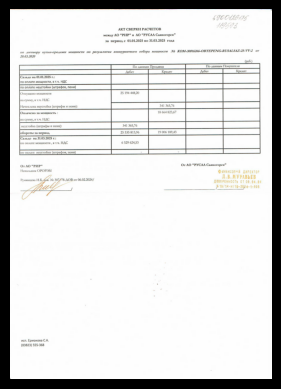

In [3]:
import matplotlib.pyplot as plt

img = loader.get_page_image(page_num=0)

plt.imshow(img)
plt.axis("off")
plt.show()



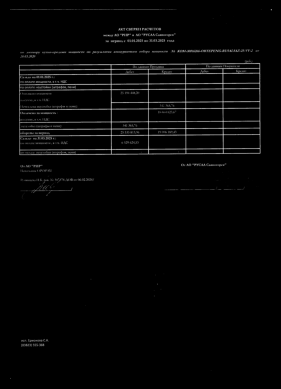

In [4]:
# бинаризация чтобы найти линии

import cv2

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

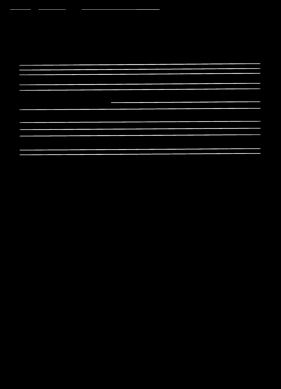

In [10]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 1))
morph = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
dilated = cv2.dilate(morph, (3, 1), iterations=2)
plt.imshow(dilated, cmap="gray")
plt.axis("off")
plt.show()

line_length: 1242.0, gap: 5


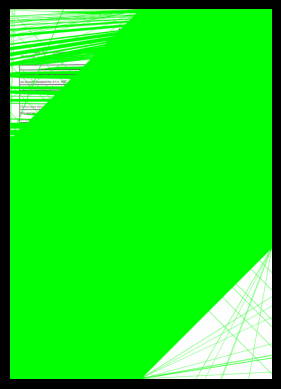

In [11]:
# find  lines
import numpy as np

line_length = img.shape[1] * 0.5 # минимальная длина линии - 30% от ширины изображения
gap = 5 # максимальный разрыв между сегментами линии, чтобы они считались одной линией
print(f"line_length: {line_length}, gap: {gap}")
inv_img = cv2.bitwise_not(dilated)
lines = cv2.HoughLinesP(inv_img, 1, np.pi / 180, threshold=100, minLineLength=line_length, maxLineGap=gap)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.imshow(img)
plt.axis("off")
plt.show()